In [1]:
import numpy as np
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from torchsummary import summary
from torchvision import datasets, transforms

# Example of LINEAR GAN

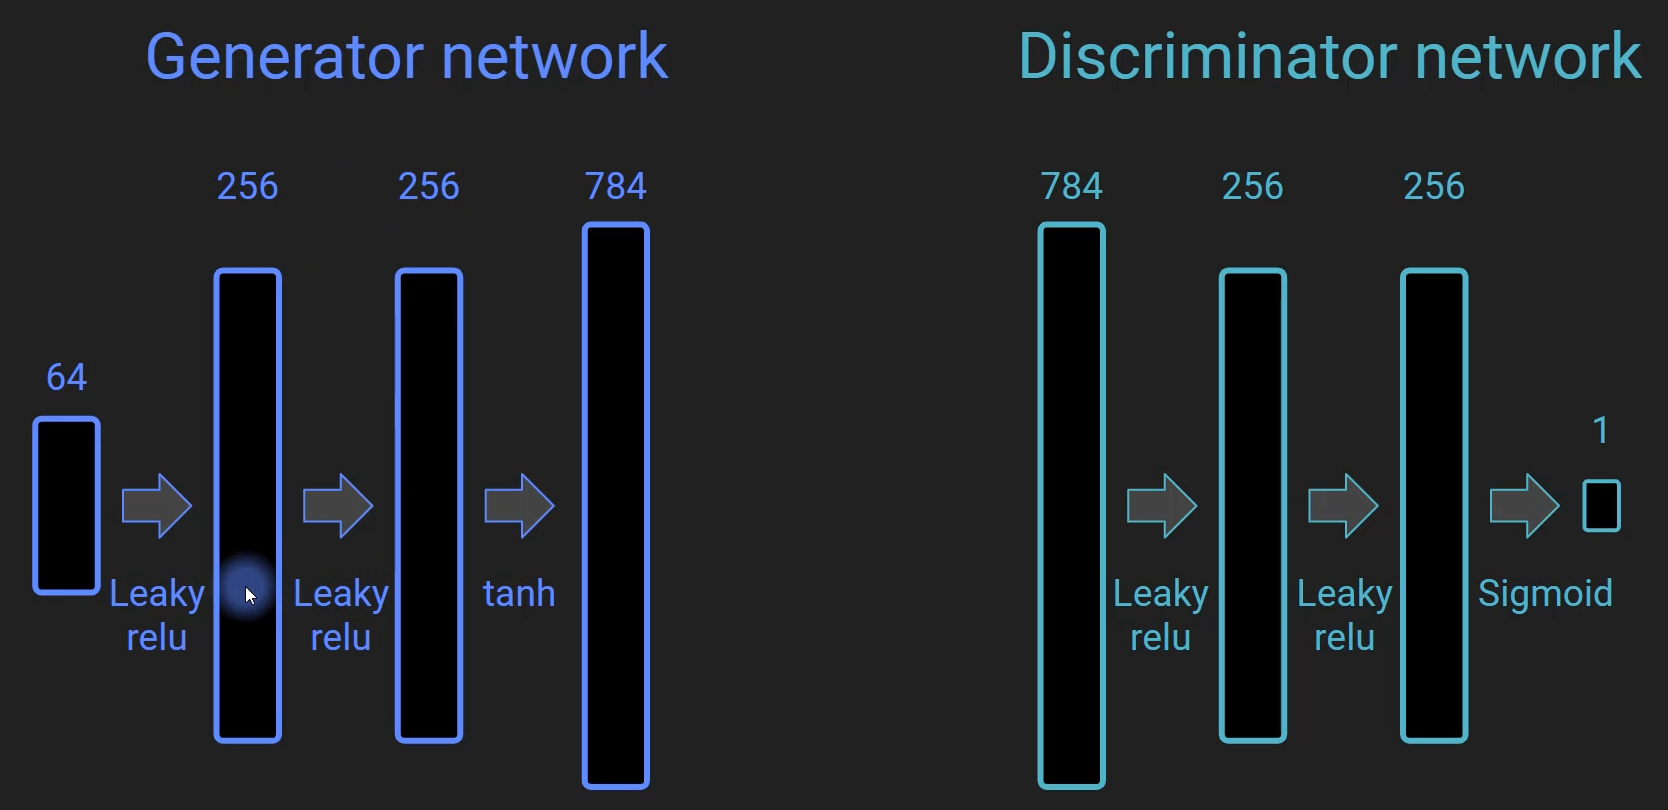

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [3]:
# import mnist dataset

transform = transforms.Compose([
    transforms.ToTensor(), 
    transforms.Normalize((0.5,), (0.5,))
])

small_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# select just 3 images (trouser, sneaker, pullover) using small_dataset.class_to_idx
class_to_idx = small_dataset.class_to_idx
print(class_to_idx)

selected_classes = ['Trouser', 'Sneaker', 'Pullover']
selected_indices = [class_to_idx[cls] for cls in selected_classes]
print(selected_indices)

small_dataset.targets = torch.tensor(small_dataset.targets)
mask = torch.isin(small_dataset.targets, torch.tensor(selected_indices))
small_dataset.data = small_dataset.data[mask]
small_dataset.targets = small_dataset.targets[mask]

data_loader = DataLoader(small_dataset, batch_size=128, shuffle=True)

{'T-shirt/top': 0, 'Trouser': 1, 'Pullover': 2, 'Dress': 3, 'Coat': 4, 'Sandal': 5, 'Shirt': 6, 'Sneaker': 7, 'Bag': 8, 'Ankle boot': 9}
[1, 7, 2]


/tmp/ipykernel_1371012/3511629871.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  small_dataset.targets = torch.tensor(small_dataset.targets)


In [4]:
# create a linear discriminator and generator model
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(28*28, 256)
        self.fc2 = nn.Linear(256, 256)
        self.fc3 = nn.Linear(256, 1)

    def forward(self, x):
        x = x.view(-1, 28*28) # flatten the input image, equivalent to nn.Flatten()
        x = F.leaky_relu(self.fc1(x))
        x = F.leaky_relu(self.fc2(x))
        x = torch.sigmoid(self.fc3(x))
        return x
    
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(64, 256) # input is a 64-dim noise vector
        self.fc2 = nn.Linear(256, 256)
        self.fc3 = nn.Linear(256, 28*28)

    def forward(self, x):
        x = F.leaky_relu(self.fc1(x))
        x = F.leaky_relu(self.fc2(x))
        x = torch.tanh(self.fc3(x)) # output is in range [-1, 1] to match the normalized input images
        x = x.view(-1, 1, 28, 28) # reshape the output to image format
        return x
    
d_net = Discriminator().to(device)
g_net = Generator().to(device)
print(summary(d_net, input_size=(1, 28, 28)))
print(summary(g_net, input_size=(64,)))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                  [-1, 256]         200,960
            Linear-2                  [-1, 256]          65,792
            Linear-3                    [-1, 1]             257
Total params: 267,009
Trainable params: 267,009
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 1.02
Estimated Total Size (MB): 1.03
----------------------------------------------------------------
None
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                  [-1, 256]          16,640
            Linear-2                  [-1, 256]          65,792
            Linear-3                  [-1, 784]         201,488
Total params: 283,920
Trainable para

Fake image shape: torch.Size([1, 28, 28])
Real image shape: torch.Size([1, 28, 28])
Discriminator output value (real): 0.45 shape: torch.Size([1, 1])
Discriminator output value (fake): 0.48 shape: torch.Size([1, 1])


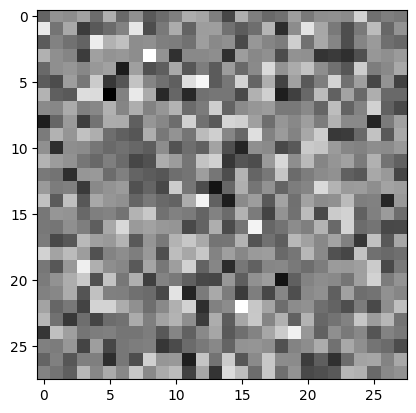

In [5]:
# test the generator and discriminator with random noise and real images
noise = torch.randn(1, 64).to(device)
fake_image = g_net(noise)[0] # generate a fake image from random noise, take the first image in the batch
real_images, _ = next(iter(data_loader))
real_image = real_images[0].to(device)

output_real = d_net(real_image)
output_fake = d_net(fake_image)


print("Fake image shape:", fake_image.shape) # should be (1, 1, 28, 28)
print("Real image shape:", real_image.shape) # should be (1, 1, 28, 28)

print(f"Discriminator output value (real): {output_real.item():.2f} shape: {output_real.shape}") # should be (1, 1) since batch size is 1
print(f"Discriminator output value (fake): {output_fake.item():.2f} shape: {output_fake.shape}") # should be (1, 1) since batch size is 1

# visualize the fake image generated by the generator
fake_image = fake_image.cpu().detach().numpy().squeeze() # convert to numpy array and remove batch and channel dimensions
plt.imshow(fake_image, cmap='gray')
plt.show()

In [6]:
# create a function to train the GAN
def train_gan(d_net, d_optimizer, g_net, g_optimizer, train_loader, loss_fn, num_epochs=10):

    losses = np.zeros((num_epochs, 2)) # to store discriminator and generator losses
    discriminator_outputs = np.zeros((num_epochs, 2)) # to store discriminator outputs for real and fake images

    for epoch in range(num_epochs):
        loss_d_epoch = 0.0
        loss_g_epoch = 0.0
        d_out_real_epoch = 0.0
        d_out_fake_epoch = 0.0
        for real_images, _ in train_loader:
            batch_size = real_images.size(0) # get the actual batch size (last batch might be smaller)
            
            # A) Train Discriminator
            # 0) Create real and fake images and labels
            real_images = real_images.to(device)
            labels_real = torch.ones(batch_size, 1).to(device) # real labels

            noise = torch.randn(batch_size, 64).to(device)
            fake_images = g_net(noise)
            labels_fake = torch.zeros(batch_size, 1).to(device) # fake labels

            # 1) Train on real images
            output_real = d_net(real_images)
            d_loss_real = loss_fn(output_real, labels_real)

            # 2) Train on fake images
            output_fake = d_net(fake_images.detach()) # detach to avoid backprop through generator
            d_loss_fake = loss_fn(output_fake, labels_fake)

            # 3) Combine losses and update discriminator
            d_out_real_epoch += output_real.mean().item() # average output for real images
            d_out_fake_epoch += output_fake.mean().item() # average output for fake images
            loss_d_epoch += d_loss_real.item() + d_loss_fake.item()
            d_loss = d_loss_real + d_loss_fake

            d_optimizer.zero_grad()
            d_loss.backward()
            d_optimizer.step()

            # B) Train Generator
            output_fake_for_g = d_net(fake_images) # don't detach here, we want gradients to flow to generator
            g_loss = loss_fn(output_fake_for_g, labels_real) # want generator to fool discriminator
            loss_g_epoch += g_loss.item()
            g_optimizer.zero_grad()
            g_loss.backward()
            g_optimizer.step()

        discriminator_outputs[epoch, 0] = d_out_real_epoch / len(train_loader) # average discriminator output for real images
        discriminator_outputs[epoch, 1] = d_out_fake_epoch / len(train_loader) # average discriminator output for fake images   
        losses[epoch, 0] = loss_d_epoch / len(train_loader) # average discriminator loss for the epoch
        losses[epoch, 1] = loss_g_epoch / len(train_loader) # average generator loss for the epoch

        print(f"Epoch [{epoch+1}/{num_epochs}] - D Loss: {loss_d_epoch/len(train_loader):.4f}, G Loss: {loss_g_epoch/len(train_loader):.4f}")

    return losses, discriminator_outputs

In [7]:
# define loss function and optimizers for discriminator and generator
loss_fn = nn.BCELoss()

d_net = Discriminator().to(device)
g_net = Generator().to(device)

optimizer_D = torch.optim.Adam(d_net.parameters(), lr=0.0003) # GANS are very sensitive to learning rates
optimizer_G = torch.optim.Adam(g_net.parameters(), lr=0.0003)

num_epochs = 500

losses, discriminator_outputs = train_gan(d_net, optimizer_D, g_net, optimizer_G, data_loader, loss_fn, num_epochs)

Epoch [1/500] - D Loss: 0.9604, G Loss: 0.6606
Epoch [2/500] - D Loss: 0.9781, G Loss: 0.9083
Epoch [3/500] - D Loss: 0.3173, G Loss: 2.2323
Epoch [4/500] - D Loss: 0.1597, G Loss: 2.8042
Epoch [5/500] - D Loss: 0.4162, G Loss: 1.7314
Epoch [6/500] - D Loss: 0.1361, G Loss: 2.8950
Epoch [7/500] - D Loss: 0.2402, G Loss: 2.1762
Epoch [8/500] - D Loss: 0.2870, G Loss: 2.0064
Epoch [9/500] - D Loss: 0.1284, G Loss: 2.6763
Epoch [10/500] - D Loss: 0.0659, G Loss: 3.4917
Epoch [11/500] - D Loss: 0.0562, G Loss: 4.6256
Epoch [12/500] - D Loss: 0.0745, G Loss: 4.3892
Epoch [13/500] - D Loss: 0.0685, G Loss: 4.6888
Epoch [14/500] - D Loss: 0.0457, G Loss: 5.4228
Epoch [15/500] - D Loss: 0.0247, G Loss: 6.2941
Epoch [16/500] - D Loss: 0.0136, G Loss: 5.9284
Epoch [17/500] - D Loss: 0.0388, G Loss: 5.2150
Epoch [18/500] - D Loss: 0.0238, G Loss: 4.9992
Epoch [19/500] - D Loss: 0.1040, G Loss: 3.9273
Epoch [20/500] - D Loss: 0.0322, G Loss: 5.0583
Epoch [21/500] - D Loss: 0.0475, G Loss: 4.5515
E

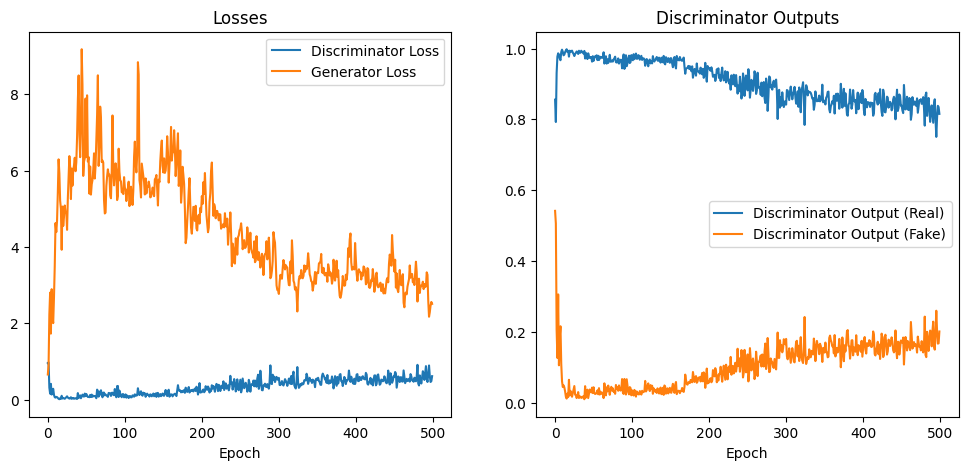

In [8]:
# plot the losses and discriminator outputs
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(losses[:, 0], label='Discriminator Loss')
plt.plot(losses[:, 1], label='Generator Loss')
plt.title('Losses')
plt.xlabel('Epoch')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(discriminator_outputs[:, 0], label='Discriminator Output (Real)')
plt.plot(discriminator_outputs[:, 1], label='Discriminator Output (Fake)')
plt.title('Discriminator Outputs')
plt.xlabel('Epoch')
plt.legend()
plt.show()
# if observed more in detail, the discriminator and generator loss iterate, this means
# that when the discriminator goes up and it starts to discriminate very well, the generator
# realizes and starts to generate better images, but then the discriminator has more issues to distinguis
# so it is a bucle, where the losses go up and down.

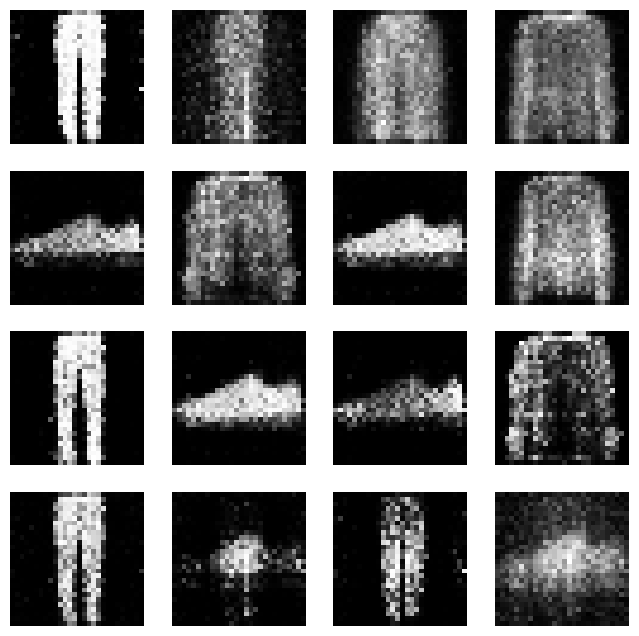

In [9]:
# visualize some samples
g_net.eval() # set generator to evaluation mode
with torch.no_grad():
    noise = torch.randn(16, 64).to(device) # generate 16 random noise vectors
    fake_images = g_net(noise).cpu() # generate fake images and move to CPU
    fake_images = fake_images.view(-1, 1, 28, 28) # reshape to image format
    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    for i in range(16):
        ax = axes[i//4, i%4]
        ax.imshow(fake_images[i].squeeze(), cmap='gray')
        ax.axis('off')
    plt.show()